In [1]:
%load_ext autoreload
%autoreload 2

In [95]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
from ariel_pred.models import TransitMultiplicationFactorFinder, SValuesCNN, SValuesCNNTrainer
from ariel_pred.features import WavelengthsGroupsMultiplierFinder
from ariel_pred.metrics import score, gll
from ariel_pred.sigma import OGSignalVarBasedSigmaCalculator, LROnVariousFeaturesSigmaCalculator
from ariel_pred.modeling.s_values_cnn_with_star_info import SValuesCNNWithStarInfoModel, SValuesCNNWithStarInfoTrainer
from ariel_pred.modeling.deep_s_values_cnn_with_star_info import DeepSValuesCNNWithStarInfoModel, DeepSValuesCNNWithStarInfoTrainer
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize
from tqdm.auto import tqdm
import pandas as pd
import torch
from torch import nn
import scipy

In [3]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)
train_data, train_labels = data_loader.load_all_train_data()
train_data.shape, train_labels.shape

Loading calibrated train data...


((1100, 1406, 283), (1100, 283))

In [4]:
features_extractor = WavelengthsGroupsMultiplierFinder()

features = features_extractor.extract_features(
    train_data,
    average_cross_groups=False,
    wavelengths_groups=[1, 2, 4, 8, 16, 32, 64],
    weights=[1, 1, 1, 1, 1, 1, 1]
)

features.shape

  0%|          | 0/1100 [00:00<?, ?it/s]

(1100, 283, 7)

In [5]:
model_data = features.transpose(0, 2,1)
model_data.shape

(1100, 7, 283)

In [6]:
star_info_df = pd.read_csv("../data/raw/train_star_info.csv")
star_info_df.head()

,planet_id,Rs,Ms,Ts,Mp,e,P,sma,i
0,34983,1.155435,1.062961,5577.006645,0.694946,0.0,3.305589,8.550786,89.150759
1,1873185,1.813230,1.370451,6216.229756,0.610845,0.0,6.352660,9.553384,88.701514
2,3849793,0.653807,0.667352,4968.477186,1.529200,0.0,5.522798,15.285661,89.134177
3,8456603,1.250623,1.162019,6023.702622,2.262107,0.0,7.541019,14.144310,87.178007
4,23615382,1.431492,1.306489,6128.061013,0.861299,0.0,4.368080,8.347654,90.000000


In [7]:
star_info = star_info_df[["Rs", "i"]].values
star_info.shape

(1100, 2)

In [96]:
trainer = DeepSValuesCNNWithStarInfoTrainer(
    Path("../models/lr_sigma_test_2"),
    n_splits=5,
    num_channels=model_data.shape[1],
    wavelengths=model_data.shape[2],
    num_star_features=star_info.shape[1]
)
val_losses, train_losses, val_preds_list = trainer.train(model_data*1e3, star_info, train_labels*1e3, epochs=300)

Fold 1/5


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Loading weights from ../models/lr_sigma_test_2/model_fold_1.pt
Fold 2/5


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Loading weights from ../models/lr_sigma_test_2/model_fold_2.pt
Fold 3/5


...

Loading weights from ../models/lr_sigma_test_2/model_fold_3.pt
Fold 4/5


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Loading weights from ../models/lr_sigma_test_2/model_fold_4.pt
Fold 5/5


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Loading weights from ../models/lr_sigma_test_2/model_fold_5.pt


In [97]:
val_preds_list.shape, train_labels.shape

((1100, 283), (1100, 283))

In [98]:
predections = val_preds_list / 1e3
np.sqrt(np.mean((predections - train_labels)**2))

np.float64(0.0006531020444773109)

In [99]:
import os
os.makedirs("../models/lr_sigma_test_2", exist_ok=True)
np.save("../models/lr_sigma_test_2/s_values_cnn_with_star_info_val_preds.npy", predections)

In [100]:
np.sqrt(np.mean((predections[:, 0] - train_labels[:, 0])**2))

np.float64(0.0008746478794264103)

In [124]:
sigma_calculator = LROnVariousFeaturesSigmaCalculator(
    mean_fgs_sigma=6.5e-4,
    mean_airs_sigma=5.5e-4,
    fgs_min_sigma=1e-6,
    airs_min_sigma=1e-6,
)
val_sigma = sigma_calculator.train(data=train_data, spectrum=predections, labels=train_labels)
train_sigma = sigma_calculator.get_sigma(data=train_data, spectrum=predections)
gll(np.concatenate([predections, val_sigma], axis=1), train_labels), gll(np.concatenate([predections, train_sigma], axis=1), train_labels)

  0%|          | 0/1100 [00:00<?, ?it/s]

Calculating AIRS sigma:   0%|          | 0/1100 [00:00<?, ?it/s]

  0%|          | 0/1100 [00:00<?, ?it/s]

Fold 1, Validation RMSE: 0.00043069781016513074
Fold 2, Validation RMSE: 0.0005988301482962582
Fold 3, Validation RMSE: 0.0004675122917142845
Fold 4, Validation RMSE: 0.0003274136027288736
Fold 5, Validation RMSE: 0.0006233622658878909


  0%|          | 0/1100 [00:00<?, ?it/s]

Calculating AIRS sigma:   0%|          | 0/1100 [00:00<?, ?it/s]

/Users/ibrahimhabib/Desktop/development/ariel-2025/.venv/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ibrahimhabib/Desktop/development/ariel-2025/.venv/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ibrahimhabib/Desktop/development/ariel-2025/.venv/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ibrahimhabib/Desktop/development/ariel-2025/.venv/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ibrahimhabib/Desktop/development/ariel-2025/.venv/lib/python3.11/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in ma

(0.42099455953666937, 0.4226523532057081)

In [106]:
residuals = np.abs(predections - train_labels)
np.abs(residuals - val_sigma).mean(), np.abs(residuals[:, 0] - val_sigma[:, 0]).mean(), np.abs(residuals[:, 1:] - val_sigma[:, 1:]).mean()

(np.float64(0.0003098796763168658),
 np.float64(0.00055714962222419),
 np.float64(0.00030900283253705265))

In [107]:
optimal_sigma = sigma_calculator._get_optimal_sigma(predections, train_labels)
optimal_sigma.shape

  0%|          | 0/1100 [00:00<?, ?it/s]

(1100,)

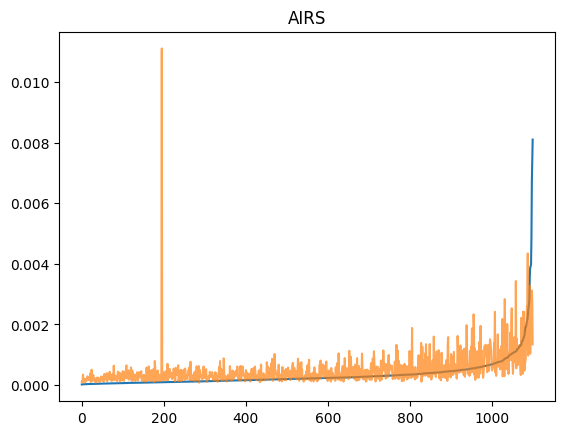

In [108]:
plt.plot(np.sort(optimal_sigma))
plt.plot(val_sigma[np.argsort(optimal_sigma), 1], alpha=0.7)
plt.title("AIRS")
plt.show()

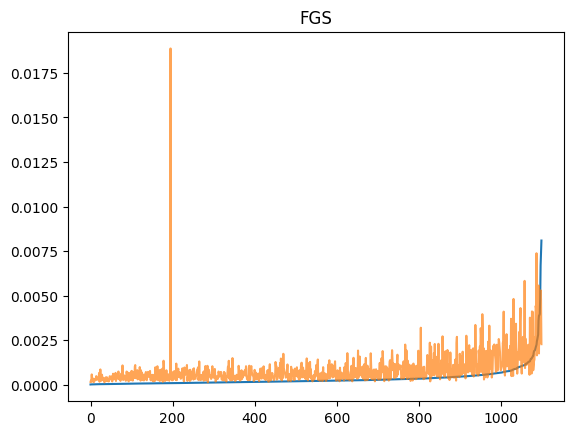

In [109]:
plt.plot(np.sort(optimal_sigma))
plt.plot(val_sigma[np.argsort(optimal_sigma), 0], alpha=0.7)
plt.title("FGS")
plt.show()

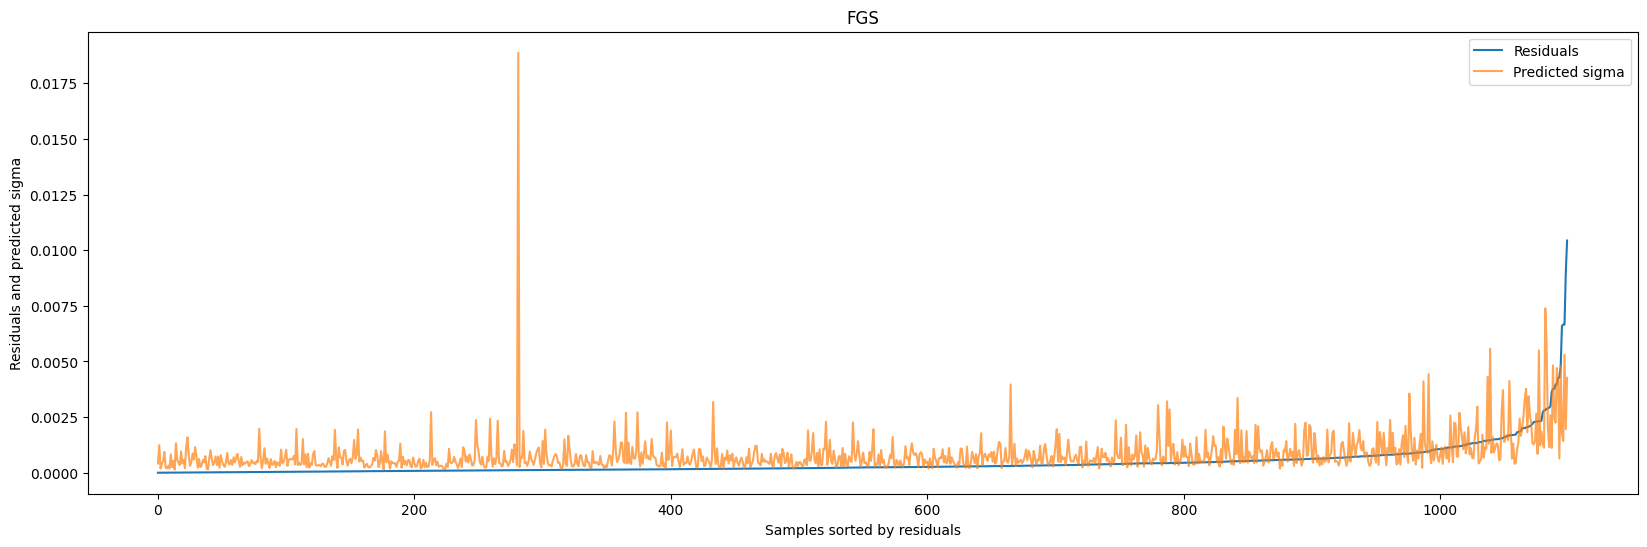

In [110]:
plt.figure(figsize=(20, 6))
plt.plot(np.sort(residuals[:, 0]))
plt.plot(val_sigma[np.argsort(residuals[:, 0]), 0], alpha=0.7)
plt.xlabel("Samples sorted by residuals")
plt.ylabel("Residuals and predicted sigma")
plt.title("FGS")
plt.legend(["Residuals", "Predicted sigma"])
plt.show()

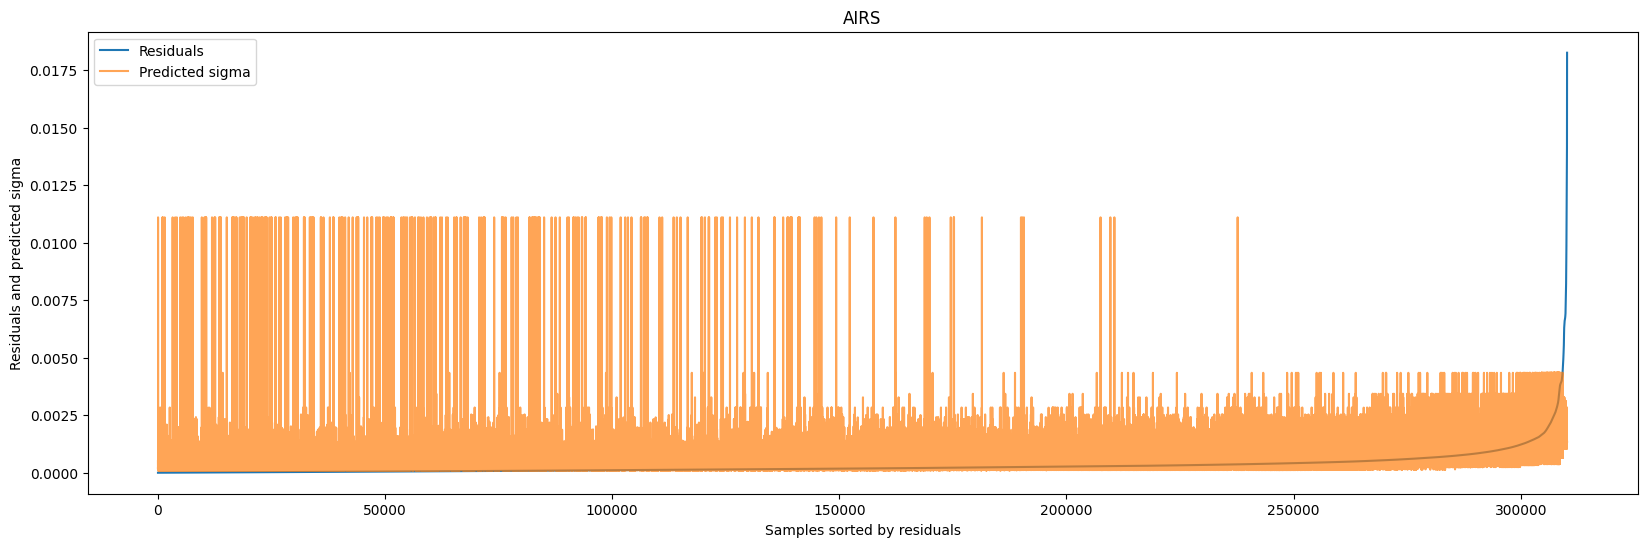

In [111]:
plt.figure(figsize=(20, 6))
plt.plot(np.sort(residuals[:, 1:].flatten()))
plt.plot(val_sigma[:, 1:].flatten()[np.argsort(residuals[:, 1:].flatten())], alpha=0.7)
plt.xlabel("Samples sorted by residuals")
plt.ylabel("Residuals and predicted sigma")
plt.title("AIRS")
plt.legend(["Residuals", "Predicted sigma"])
plt.show()

In [66]:
for model in sigma_calculator.models:
    print(model.coef_ / model.coef_.sum(), model.intercept_)
# sigma_calculator.models[3].coef_, sigma_calculator.models[1].intercept_

[9.03492282e-04 9.93128184e-01 5.96832337e-03] -9.934389781071862e-05
[1.71380175e-04 9.96979848e-01 2.84877209e-03] -7.82980710226419e-05
[0.00813248 0.94334427 0.04852325] -7.518988600200871e-05
[3.48341045e-04 9.97411172e-01 2.24048737e-03] -8.673382720360355e-05
[5.37043109e-06 9.99952122e-01 4.25070873e-05] 3.2820199677128375e-05
